# Tutorial: user-defined clumping models with classito + Cobaya

This notebook walks through the full `classito-cobaya` workflow on a toy model:

1. compute a fiducial ΛCDM spectrum;
2. write a clumping model that supplies $\sigma_{\rm e}^2(z)$ and $\Delta_c(z)$;
3. hand it to Cobaya alongside the `classito` theory wrapper and evaluate it at a point;
4. compare the resulting $C_\ell$ to the fiducial.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cobaya.model import get_model

from classito_cobaya import ClumpingModel

## Settings shared by every run

classito's modified photon hierarchy works only in Newtonian gauge, with the radiation-streaming
approximation off and tight coupling ending well before recombination. It refuses to run otherwise.
We use the same settings for the fiducial, so the comparison isolates the effect of clumping and
not the change in precision settings.

In [4]:
ito_settings = {
    "gauge": "newtonian",
    "radiation_streaming_approximation": 3,          # off
    "tight_coupling_trigger_tau_c_over_tau_h": 0.005,
    "tight_coupling_trigger_tau_c_over_tau_k": 0.008,
}

# Planck 2018 best fit
lcdm = {"H0": 67.36, "omega_b": 0.02237, "omega_cdm": 0.1200,
        "A_s": 2.100e-9, "n_s": 0.9649, "tau_reio": 0.0544}

lmax = 2500
cl_request = {"Cl": {"tt": lmax, "te": lmax, "ee": lmax}}

## 1. Fiducial ΛCDM

We use the trivial `one` likelihood to force a Theory computation and request the $C_\ell$ directly with `add_requirements`. (The warning that
the theory "does not appear to be used" refers to the moment before that request is added, and can be ignored.)

In [5]:
fiducial = get_model({
    "params": dict(lcdm),
    "likelihood": {"one": None},
    "theory": {"classy": {"extra_args": dict(ito_settings)}},
})
fiducial.add_requirements(cl_request)
fiducial.logposterior({})
cl_fid = fiducial.provider.get_Cl(ell_factor=True)   # D_ell in muK^2

[classy] `classy` module loaded successfully from /Users/gabe/opt/miniforge3/envs/clumpy/lib/python3.10/site-packages
[model] *WARNING* Theories {classy} do not appear to be actually used for anything


## 2. A clumping model: late-onset clumping

As an example, suppose a process switches on electron-density fluctuations at a redshift $z_{\rm on}$,
after which the variance stays at a constant level $A$. The coherence length is a fixed comoving
$\Delta_0$:

$$
\sigma_{\rm e}^2(z) = \frac{A}{2}\left[1 - \tanh\!\left(\frac{\ln\frac{1+z}{1+z_{\rm on}}}{w}\right)\right],
\qquad
\Delta_c(z) = \Delta_0 .
$$

Because $\sigma_{\rm e}^2$ goes to zero above $z_{\rm on}$ and to $A$ below it, it stays inside
classito's tabulated range $[0, 2]$ for any $A \le 2$. The variance varies across recombination
when $z_{\rm on}$ is near $z_* \approx 1090$, so the model is distinct from the constant-$\sigma_{\rm e}^2$
case.

A model is a subclass of `ClumpingModel` that overrides two methods:

- `get_can_support_params` lists every parameter the model reads. This step is required: Cobaya
  otherwise routes unclaimed parameters to CLASS, which rejects them as unknown.
- `clumping_functions` returns $(\sigma_{\rm e}^2, \Delta_c)$ on the redshift grid `z` that the
  wrapper requests. $\Delta_c$ is a comoving length in Mpc; classito forms
  $\tau_c = \Delta_c\,\dot\kappa$ itself.

In [6]:
class LateOnsetClumping(ClumpingModel):
    # Clumping that switches on below z_on and saturates at amplitude A.

    def get_can_support_params(self):
        return ["clump_A", "clump_z_on", "clump_width", "clump_Delta0"]

    def clumping_functions(self, z, **params):
        x = np.log((1. + z) / (1. + params["clump_z_on"])) / params["clump_width"]
        sigma_e2 = 0.5 * params["clump_A"] * (1. - np.tanh(x))
        Delta_c = np.full_like(z, params["clump_Delta0"])   # comoving Mpc
        return sigma_e2, Delta_c

## 3. Wire it into Cobaya

The theory block has two components:

- `classito_cobaya.classito` replaces Cobaya's `classy`. It requires the product `ito_clumping`. 
- In a notebook we pass the class itself through
  `external`; in a YAML file you would give its module path instead, e.g.
  `my_module.LateOnsetClumping: {provides: [ito_clumping]}` (see `example.yaml`).

The clumping parameters get priors like any other sampled parameter, and the onset width is
fixed. The wrapper samples the functions at `ito_nodes` points (48 by default) spaced
logarithmically in $1+z$, about 0.16 apart in $\ln(1+z)$, and classito splines between them. The
width $w = 0.25$ puts about five nodes across the onset. A sharper feature needs a larger
`ito_nodes` in the `classito_cobaya.classito` block.

In [7]:
params = dict(lcdm)
params.update({
    "clump_A":      {"prior": {"min": 0.,   "max": 2.},    "latex": r"A"},
    "clump_z_on":   {"prior": {"min": 500., "max": 5000.}, "latex": r"z_{\rm on}"},
    "clump_Delta0": {"prior": {"min": 0.,   "max": 10.},   "latex": r"\Delta_0\,[{\rm Mpc}]"},
    "clump_width":  0.25,
})

model = get_model({
    "params": params,
    "likelihood": {"one": None},
    "theory": {
        "classito_cobaya.classito": {
            "extra_args": {"has_ito": "yes", "ito_input_mode": "table", **ito_settings},
            "stop_at_error": True,
        },
        "clumping": {"external": LateOnsetClumping, "provides": ["ito_clumping"]},
    },
})
model.add_requirements(cl_request)

[classito_cobaya.classito] `classy` module loaded successfully from /Users/gabe/opt/miniforge3/envs/clumpy/lib/python3.10/site-packages
[model] *WARNING* Theories {clumping, classito_cobaya.classito} do not appear to be actually used for anything


### Evaluate at a point

In [8]:
point = {"clump_A": 0.2, "clump_z_on": 1500., "clump_Delta0": 1.}
model.logposterior(point)

cl = model.provider.get_Cl(ell_factor=True)
clumping = model.provider.get_ito_clumping()

print(f"{len(clumping['z'])} nodes, z in [{clumping['z'][0]:.0f}, {clumping['z'][-1]:.0f}]")

48 nodes, z in [10, 20000]


As a sanity check, setting the amplitude to zero should reproduce the fiducial:

In [13]:
model.logposterior({**point, "clump_A": 0.})
cl_zero = model.provider.get_Cl(ell_factor=True)
ells = slice(2, lmax + 1)
print("max |C_l / C_l^fid - 1| at A = 0:",
      max(np.max(np.abs(cl_zero[s][ells] / cl_fid[s][ells] - 1)) for s in ("tt", "ee")))

_ = model.logposterior(point)   # restore the point of interest

max |C_l / C_l^fid - 1| at A = 0: 1.197566046329257e-09


## 4. Results

First, the functions the model handed to classito. Outside the node grid classito holds both
functions at their endpoint values. For this model that is $\sigma_{\rm e}^2 = A$ below
$z_{\rm min}$ and 0 above $z_{\rm max}$. The dotted line marks $z_* \approx 1090$.

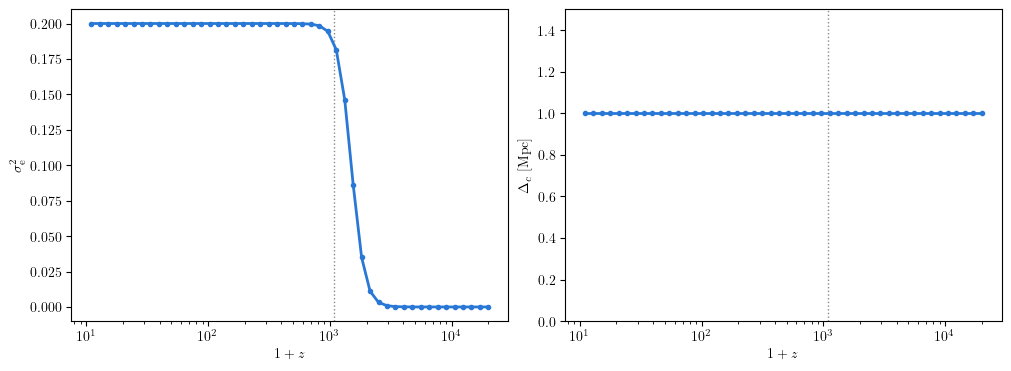

In [14]:
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#8a8985"
Z_STAR = 1090.

def mark_recombination(ax):
    ax.axvline(1 + Z_STAR, color=GRAY, lw=1, ls=":", zorder=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
onezp = 1 + clumping["z"]

axes[0].plot(onezp, clumping["sigma_e2"], color=BLUE, lw=2, marker="o", ms=3)
axes[0].set_ylabel(r"$\sigma_{\rm e}^2$")
axes[1].plot(onezp, clumping["Delta_c"], color=BLUE, lw=2, marker="o", ms=3)
axes[1].set_ylabel(r"$\Delta_c$ [Mpc]")
axes[1].set_ylim(0, 1.5 * point["clump_Delta0"])

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel(r"$1+z$")
    mark_recombination(ax)
plt.show()

Next, the change in the spectra relative to the fiducial. TE crosses zero, so its difference is
normalised by $\sqrt{D_\ell^{TT} D_\ell^{EE}}$ instead of by itself.

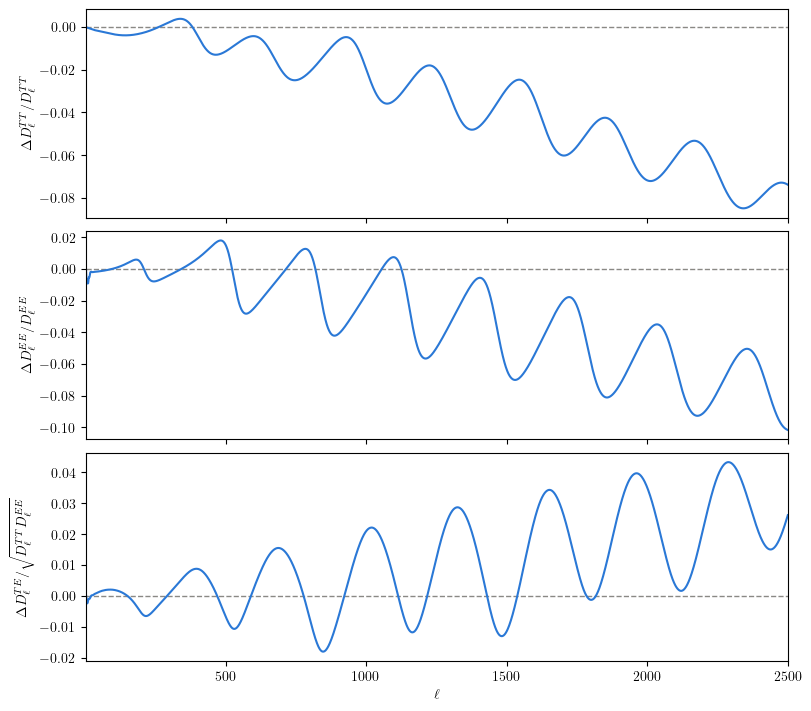

In [16]:
ell = cl["ell"][ells]

def residuals(c):
    tt = c["tt"][ells] / cl_fid["tt"][ells] - 1
    ee = c["ee"][ells] / cl_fid["ee"][ells] - 1
    te = (c["te"][ells] - cl_fid["te"][ells]) / np.sqrt(cl_fid["tt"][ells] * cl_fid["ee"][ells])
    return tt, ee, te

labels = (r"$\Delta D_\ell^{TT} / D_\ell^{TT}$",
          r"$\Delta D_\ell^{EE} / D_\ell^{EE}$",
          r"$\Delta D_\ell^{TE} / \sqrt{D_\ell^{TT} D_\ell^{EE}}$")

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
for ax, r, label in zip(axes, residuals(cl), labels):
    ax.axhline(0, color=GRAY, linestyle="dashed", lw=1)
    ax.plot(ell, r, color=BLUE, lw=1.5)
    ax.set_ylabel(label)
axes[-1].set_xlabel(r"$\ell$")
axes[-1].set_xlim(2, lmax)
plt.show()

### Dependence on the onset redshift

An onset after the peak of the visibility function ($z_{\rm on} = 1000$) produces only
percent-level oscillatory changes. With an earlier onset, more of recombination proceeds at the full
variance, and the damping tail is suppressed more strongly.

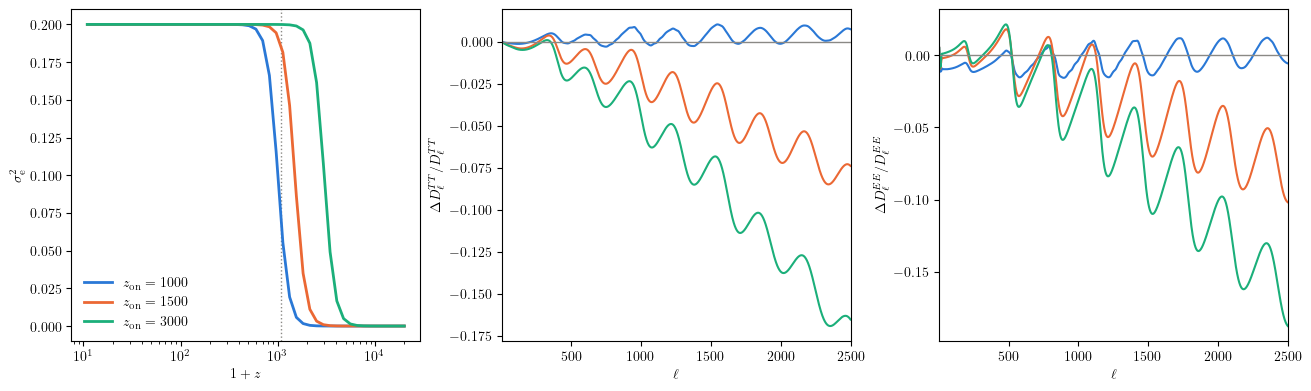

In [17]:
scan = {}
for z_on in (1000., 1500., 3000.):
    model.logposterior({**point, "clump_z_on": z_on})
    scan[z_on] = (model.provider.get_ito_clumping(), model.provider.get_Cl(ell_factor=True))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
for color, (z_on, (clump, c)) in zip((BLUE, ORANGE, AQUA), scan.items()):
    label = rf"$z_{{\rm on}} = {z_on:.0f}$"
    axes[0].plot(1 + clump["z"], clump["sigma_e2"], color=color, lw=2, label=label)
    tt, ee, _ = residuals(c)
    axes[1].plot(ell, tt, color=color, lw=1.5, label=label)
    axes[2].plot(ell, ee, color=color, lw=1.5, label=label)

axes[0].set_xscale("log")
axes[0].set_xlabel(r"$1+z$")
axes[0].set_ylabel(r"$\sigma_{\rm e}^2$")
mark_recombination(axes[0])
for ax, label in zip(axes[1:], labels[:2]):
    ax.axhline(0, color=GRAY, lw=1)
    ax.set_xlabel(r"$\ell$")
    ax.set_xlim(2, lmax)
    ax.set_ylabel(label)
axes[0].legend(frameon=False)
plt.show()

## Next steps

To run an MCMC on this model, move `LateOnsetClumping` into an importable module, reference it
by path in the `theory` block, and add real likelihoods. `examples/example.yaml` is a complete
starting point. Check that $\sigma_{\rm e}^2$ stays in $[0, 2]$ over the whole prior. If it
doesn't, classito raises an error, and with `stop_at_error: False` a sampler silently discards the
point, which truncates the posterior.